In [53]:
%matplotlib inline

# Module 3 - Programming Assignment

## General Directions

1. You must follow the Programming Requirements outlined on Canvas.
2. The Notebook should be cleanly and fully executed before submission.
3. You should change the name of this file to be your JHED id. For example, `jsmith299.ipynb` although Canvas may change it to something else...and that's ok.

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>
        You should always read the entire assignment before beginning your work, so that you know in advance what the requested output will be and can plan your implementation accordingly.
    </p>
</div>

<div style="color: white; background: #C83F49; margin:20px; padding: 20px;">
    <strong>Academic Integrity and Copyright</strong>
    <p>You are not permitted to consult outside sources (Stackoverflow, YouTube, ChatGPT, etc.) or use "code assistance" (Co-Pilot, etc) to complete this assignment. By submitting this assignment for grading, you certify that the submission is 100% your own work, based on course materials, group interactions, instructor guidance. You agree to comply by the requirements set forth in the Syllabus, including, by reference, the JHU KSAS/WSE Graduate Academic Misconduct Policy.</p>
    <p>Sharing this assignment either directly (e.g., email, github, homework site) or indirectly (e.g., ChatGPT, machine learning platform) is a violation of the copyright. Additionally, all such sharing is a violation the Graduate Academic Misconduct Policy (facilitating academic dishonesty is itself academic dishonesty), even after you graduate.</p>
    <p>If you have questions or if you're unsure about the policy, ask via Canvas Inbox. In this case, being forgiven is <strong>not</strong> easier than getting permission and ignorance is not an exuse.</p>
    <p>This assignment is copyright (&copy Johns Hopkins University &amp; Stephyn G. W. Butcher). All rights reserved.</p>
</div>

# The Problem

When we last left our agent in Module 1, it was wandering around a world filled with plains, forests, swamps, hills and mountains. This presupposes a map with known terrain:

```
......
...**.
...***
..^...
..~^..
```

but what if all we know is that we have some area of interest, that we've reduced to a GPS grid:

```
??????
??????
??????
??????
??????
```

and the agent has to determine what kind of terrain is to the left, front and right of it?

Assuming the agent has a very simple visual sensor that constructs a 4x4 grayscale image for each of the three directions, it might it could see something like this:

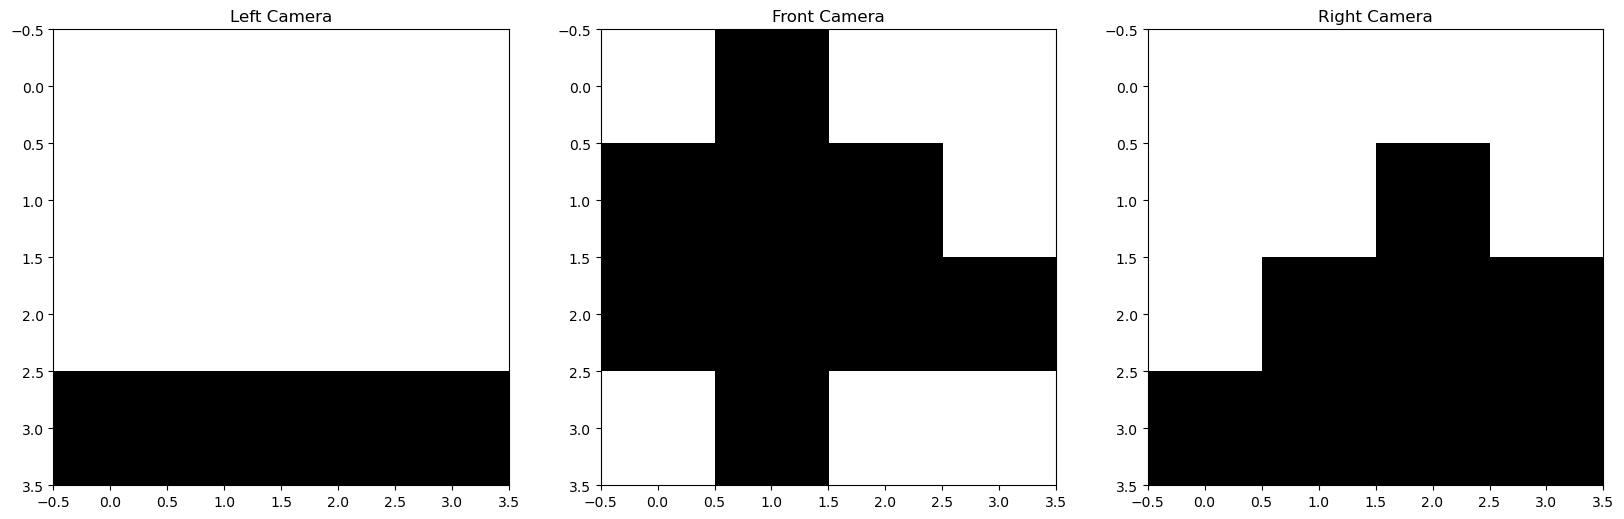

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import random

plain =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0]
forest = [0.0, 1.0, 0.0, 0.0,1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0]
hills =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
swamp =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]

figure = plt.figure(figsize=(20,6))

axes = figure.add_subplot(1, 3, 1)
pixels = np.array([255 - p * 255 for p in plain], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Left Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 2)
pixels = np.array([255 - p * 255 for p in forest], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Front Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 3)
pixels = np.array([255 - p * 255 for p in hills], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Right Camera")
axes.imshow(pixels, cmap='gray')

plt.show()
plt.close()

which would be plains, forest and hills respectively.

## The Assignment

For this programming assignment your tasks are:

1. Write a logistic regression that simply determines if something is a hill or not (two class problem). 
2. You will also evaluate that logistic regression by generating a *confusion matrix*.

For a starting point, refer to the Pseudocode and the Self-Check.

## Data

We have clean examples of the different types of terrain but based on the location, the registration can be a bit off for some of the types and the visual sensor is often noisy.

Here are the clean examples with different registrations: 

In [55]:
clean_data = {
    "plains": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, "plains"]
    ],
    "forest": [
        [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, "forest"],
        [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, "forest"]
    ],
    "hills": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, "hills"]
    ],
    "swamp": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "swamp"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, "swamp"]        
    ]
}

Let's create a function that allows us to view any of these:

In [56]:
def view_sensor_image(data):
    figure = plt.figure(figsize=(4,4))
    axes = figure.add_subplot(1, 1, 1)
    pixels = np.array([255 - p * 255 for p in data[:-1]], dtype='uint8')
    pixels = pixels.reshape((4, 4))
    axes.set_title( "Left Camera:" + data[-1])
    axes.imshow(pixels, cmap='gray')
    plt.show()
    plt.close()

"I think that I shall never see a thing so lovely as a tree."

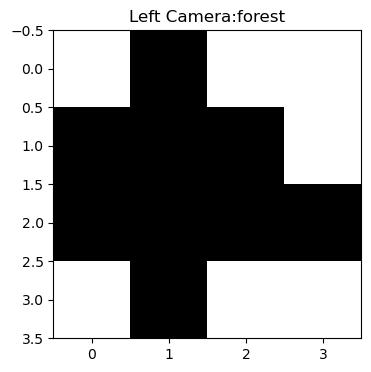

In [57]:
view_sensor_image( clean_data[ "forest"][0])

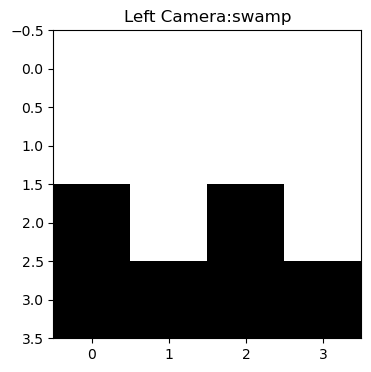

In [58]:
view_sensor_image( clean_data["swamp"][0])

The data that comes in, however, is noisy. The values are never exactly 0 and 1. In order to mimic this we need a `blur` function.

We will assume that noise is normally distributed. For values that should be 0, the noisy values are distributed $N(0.10, 0.05)$. For values that should be 1, the noisy values are distributed $N(0.9, 0.10)$.

In [59]:
def blur( data):
    def apply_noise( value):
        if value < 0.5:
            v = random.gauss(0.30, 0.07) # (0.10, 0.05)
            if v < 0.0:
                return 0.0
            if v > 0.75:
                return 0.75
            return v
        else:
            v = random.gauss(0.70, 0.07) # (0.90, 0.10)
            if v < 0.25:
                return 0.25
            if v > 1.00:
                return 1.00
            return v
    noisy_readings = [apply_noise( v) for v in data[0:-1]]
    return noisy_readings + [data[-1]]

We can see how this affects what the agent *actually* sees.

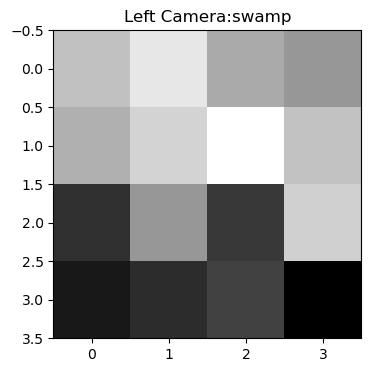

In [60]:
view_sensor_image(blur(clean_data["swamp"][0]))

We need four (4) functions:

1. `generate_data`
2. `learn_model`
3. `apply_model`
4. `evaluate`

### generate_data

`generate_data` has been written for you.

* clean_data - the clean versions of the "bitmaps" for each of the terrain types
* n - the number of samples for "in the class" (1) and "not in the class" (0) to generate.
* label - the label to chose as "in the class".

For example,

`generate_data( clean_data, 100, "hills")`

generates 100 hills, 100 not hills and has transformed the String labels into 1 and 0, respectively.

### `learn_model`

`learn_model` is the function that takes in training data and actually learns the logistic regression model.

*In the lecture, I mentioned that you usually should mean normalize your data but you don't need to do that in this case because the data is already on the range 0-1.*

For this problem, an `epsilon` of 1e-5 is a good balance between accuracy and time to convergence. Additionally, it'll make sure we all generally get the same results. You should start with an `alpha` of 0.1 and then make it adaptive as described in the Pseudocode.

When developing your algorithm, you need to watch the error so you'll set verbose=True to start. You should print it out every iteration and make sure it is declining. You don't need to run it to convergence...you'll know pretty quickly if you're doing the right thing. When you know that your algorithm is working, change your code so that the error is printed out only every 1,000 iterations (it takes a lot of iterations for this problem to converge, depending on your parameter values--start early).

`learn_model` returns the List of Thetas.

### `apply_model`

`apply_model` takes a List of Thetas (the model) and lableled data. You will return a List of Tuples. Each Tuple will contain the actual $y$ value and the predicted y value ($\hat{y}) as the probability.

### `evaluate`

Ideally, we should be doing the model evaluation things we learned this module. Instead, we're just going to print out:

1. the error rate
2. a confusion matrix.

```
{"TN": 0, "TP": 0, "FN": 0, "FP": 0}
```
The main reason we're not going to do more is that the full 5x2 cross validation, validation curves, learning curves approach to model evaluation would take too long with this algorithm (at least as an assignment). In the real world, you would just have to bite the bullet and do it although the algorithm could be run in parallel and the results combined.

We will ask you to do these things on later assignments so be prepared.

**As always when working with Lists or Lists of Lists, be very careful when you are modifying these items in place that this is what you want.**

<a id="prepend_bias"></a>
## prepend_bias

`prepend_bias` prepends each data row in the dataset with a "1" which corresponds to the 'imaginary' observation associated with theta_0, the bias term.  **Used by**: [learn_model](#learn_model), [apply_model](#apply_model)

* **data** list[tuple[list, int]]: the input data values that will get the prepended 1's.

**returns** list[tuple[list, int]]: the updates observations.

In [61]:
def prepend_bias(data: list[tuple[list, int]]) -> list[tuple[list, int]]:
    for row in data:
        row[0].insert(0, 1.0)
    return data

In [62]:
data = [([], 1)]
assert prepend_bias(data) == [([1], 1)]
data = [([1, 2, 3], 1)]
assert prepend_bias(data) == [([1, 1, 2, 3], 1)]
data = [([1, 2, 3], 0), ([4, 5, 6], 1)]
assert prepend_bias(data) == [([1, 1, 2, 3], 0), ([1, 4, 5, 6], 1)]


<a id="sigmoid"></a>
## sigmoid

`sigmoid` calculates the result of the sigmoid function, 1/(1+exp(-(theta*vals))) for a vector of thetas and values. **Used by**: [calculate_error](#calculate_error), [derivative](#derivative), [apply_model](#apply_model)

* **thetas** list[float]: the theta values to use in the function, i.e. logistic regression parameter estimates.
* **vals** list[float]: the values to use in the function, i.e. the real-valued data for calculations.


**returns** float: the result of the function given the input vectors thetas and vals.

In [63]:
def sigmoid(thetas: list[float], vals: list[float]) -> float:
    x = 0.0
    for theta, val in zip(thetas, vals):
        x += theta*val
    result = 1 / (1 + np.exp(-x))
    return result

In [64]:
thetas = [0, 0, 0]; vals = [0, 0, 0]
assert sigmoid(thetas=thetas, vals=vals) == 0.5
thetas = [1]; vals = [1]
assert np.isclose(sigmoid(thetas=thetas, vals=vals), 0.7310585)
thetas = [9999]; vals = [1]
assert sigmoid(thetas=thetas, vals=vals) == 1.0


<a id="calculate_error"></a>
## calculate_error

`calculate_error` calculates the error as defined with cross entropy loss, for use in gradient descent. **Uses:** [sigmoid](#sigmoid) **Used by**: [learn_model](#learn_model)

* **thetas** list[float]: the theta values to use in the function, i.e. logistic regression parameter estimates.
* **data** list[tuple[list, int]]: the values to use in the function, i.e. the real-valued data for calculations.

**returns** float: the error as calculated by using cross entropy loss.

In [65]:
def calculate_error(thetas: list[float], data: list[tuple[list, int]]) -> float:
    J = 0.0
    for row in data:
        yi = row[1]
        yi_hat = sigmoid(thetas=thetas, vals=row[0])
        J += yi * np.log(yi_hat) + (1 -  yi) * np.log(1 - yi_hat)
    J *= -1 / len(data)
    return J

In [66]:
thetas = [0.8, 1.1]; data = [([1.0, 1.1], 0), ([1.0, 2.7], 1)]
J = calculate_error(thetas=thetas, data=data)
assert np.isclose(J, 1.07927)
thetas = [0.0]; data = [([0.0], 0), ([0.0], 0)]
J = calculate_error(thetas=thetas, data=data)
assert np.isclose(J, 0.69315)
thetas = [1.0]; data = [([1.0], 1), ([0.0], 0)]
J = calculate_error(thetas=thetas, data=data)
assert np.isclose(J, 0.5032)


<a id="derivative"></a>
## derivative

`derivative` calculates the partial derivate of the loss function with respect to a particular theta_j, used in updating each theta. **Uses:** [sigmoid](#sigmoid) **Used by**: [learn_model](#learn_model)

* **j** list[float]: the particular j used to index into the observation, corresponding to the theta that will be updated.
* **thetas** list[float]: the theta values to use in the function, i.e. logistic regression parameter estimates.
* **data** list[tuple[list, int]]: the values to use in the function, i.e. the real-valued data for calculations.

**returns** float: the partial derivative value.

In [67]:
def derivative(j: int, thetas: list[float], data: list[tuple[list, int]]) -> float:
    dJ = 0.0
    for row in data:
        xij = row[0][j]
        yi = row[1]
        yi_hat = sigmoid(thetas=thetas, vals=row[0])
        dJ += (yi_hat - yi) * xij
    dJ *= 1 / len(data)
    return dJ

In [68]:
j = 0; thetas=[0.8, 1.1]; data=[([1, 1.1], 0), ([1, 2.7], 1)]
assert np.isclose(derivative(j=j, thetas=thetas, data=data), 0.429655)
j = 0; thetas=[0.8, 1.1]; data=[([0, 0.0], 0), ([1, 2.7], 1)]
assert np.isclose(derivative(j=j, thetas=thetas, data=data), -0.0112663)
j = 0; thetas=[0.8, 1.1]; data=[([0, 0.0], 0), ([0, 0.0], 1)]
assert np.isclose(derivative(j=j, thetas=thetas, data=data), 0.0)

---

Put your helper functions above here.

## Main Functions

Use `generate_data` to generate a balanced set of blurred "hills" and "not-hills" examples to test that the function is working.

In [69]:
def generate_data(data: dict[str, list[list[float]]], n: int, key_label: str) -> list[tuple[list, int]]:
    labels = list(data.keys())
    labels.remove(key_label)

    total_labels = len(labels)
    result = []
    # create n "not label" and code as y=0
    count = 1
    while count <= n:
        label = labels[count % total_labels]
        datum = blur(random.choice(data[label]))
        xs = datum[0:-1]
        result.append((xs, 0))
        count += 1

    # create n "label" and code as y=1
    for _ in range(n):
        datum = blur(random.choice(data[key_label]))
        xs = datum[0:-1]
        result.append((xs, 1))
    random.shuffle(result)
    return result

In [70]:
results = generate_data(clean_data, 5, "hills")
for result in results:
    print(result)

([0.19321579292029706, 0.264045179675205, 0.0684859691717, 0.33168605134912404, 0.31016821358023006, 0.2450432688140519, 0.27565692454407054, 0.34484227516141097, 0.3312402404200814, 0.6793959354938598, 0.3601520532182565, 0.6963824482604618, 0.6297052857694392, 0.6141940372686322, 0.609496606026512, 0.5701269965151474], 0)
([0.3384217135840816, 0.33640984207300606, 0.31495818504385664, 0.43817753371210655, 0.32893021652030285, 0.6779721592214142, 0.30132678189084006, 0.2585923941430852, 0.7340127855518042, 0.8160797487741173, 0.6958157218774927, 0.40458571110682107, 0.6255050818660265, 0.7288299228960928, 0.6263482067736955, 0.8132862537043413], 1)
([0.3542256794237842, 0.32856198385796126, 0.7778247792350803, 0.39564646042703977, 0.26968588434196045, 0.703618498331552, 0.6786798903115168, 0.7846396633331055, 0.9003862960342485, 0.8336933789909501, 0.6491979332422543, 0.7330659194951836, 0.33055916927674633, 0.2027758813505073, 0.6521329376652155, 0.32805116939805806], 0)
([0.29751772

<a id="learn_model"></a>
## learn_model

`learn_model` trains a one-vs-rest logistic regression classifier for hills vs not hills, using gradient descent. It also uses an adaptive learning rate that decreases as the iterations increase. **Uses:** [prepend_bias](#prepend_bias), [calculate_error](#calculate_error), [derivative](#derivative)

* **data** list[tuple[list, int]]: the pixel values from our simulated cameras, along with the truth labels.
* **verbose** bool: whether to print the error at every iteration or only every 1000 iterations.

**returns** list[float]: the theta values after running gradient descent until convergence (linear model parameters).

In [71]:
def learn_model(data: list[tuple[list, int]], verbose: bool=False) -> list[float]:
    epsilon = 1e-5; alpha = 0.1; iter = 0
    data = prepend_bias(data=data) 
    num_thetas = len(data[0][0])
    thetas = [random.uniform(-1, 1) for _ in range(num_thetas)]
    previous_error = 0.0
    current_error = calculate_error(thetas=thetas, data=data)
    while abs(current_error - previous_error) > epsilon:
        new_thetas = []
        for j in range(len(thetas)):
            new_thetas.append(thetas[j] - alpha * derivative(j, thetas, data))
        thetas = new_thetas
        previous_error = current_error
        current_error = calculate_error(thetas=thetas, data=data)
        iter += 1
        if verbose or iter % 1000 == 0:
            print("iter ", iter, "current error ", current_error)
        if iter % 1000 == 0: alpha *= 0.9
    return thetas

<a id="apply_model"></a>
## apply_model

`apply_model` uses previously learned linear model parameters (our thetas from learn_model) to predict labels using a logit link function. **Uses:** [prepend_bias](#prepend_bias), [sigmoid](#sigmoid)

* **model** list[float]: the list of model parameters (thetas) from our gradient descent algorithm, for use in predicting class labels.
* **test_data** list[tuple[list, int]]: the pixel values from our simulated cameras, along with the truth labels. Expected to be previously partitioned off as a test set from the original dataset.

**returns** list[tuple]: a list of tuples with the first element in each tuple representing the probability of a positive predicted label and second element representing the truth label.

In [72]:
def apply_model(model: list[float], test_data: list[tuple[list, int]]) -> list[tuple]:
    data = prepend_bias(data=test_data)
    results = []
    for row in data:
        truth = row[1]
        vals = row[0]
        estimate = sigmoid(thetas=model, vals=vals)
        results.append((estimate, truth))
    return results

<a id="evaluate"></a>
## evaluate

`evaluate` evalutes the results from a logistic regression classifier, and prints out the error rate as well as confusion matrix parameters. It uses maximum likelihood thresholding to assign a class for the predicted label. It does not return anything.

* **results** list[tuple]: a list of tuples with the first element in each tuple representing the probability of a positive predicted label and second element representing the truth label.

In [73]:
def evaluate(results: list[tuple]) -> None:
    conf_matrix = {"TN": 0, "TP": 0, "FN": 0, "FP": 0}
    for r in results:
        if round(r[0]) == 0 and r[1] == 0:
            conf_matrix["TN"] += 1
        elif round(r[0]) == 1 and r[1] == 1:
            conf_matrix["TP"] += 1
        elif round(r[0]) == 0 and r[1] == 1:
            conf_matrix["FN"] += 1
        elif round(r[0]) == 1 and r[1] == 0:
            conf_matrix["FP"] += 1
    error_rate = (conf_matrix["FN"] + conf_matrix["FP"]) / (len(results))
    print("error_rate: ", error_rate)
    print(conf_matrix)



## Use your code

Use `generate_data` to generate 100 blurred "hills" examples balanced with 100 "non hills" examples and use this as your test data. Print out the first 10 results, one per line.

In [74]:
train_data = generate_data(clean_data, 100, "hills")
for i in range(10):
    print(train_data[i])

([0.3505442696657691, 0.25342395745331886, 0.24473039279160907, 0.34726253094906756, 0.41771315991492813, 0.7809095511570656, 0.37903634659648877, 0.39709997685054454, 0.7059655150863858, 0.7184570810390658, 0.7546765051592044, 0.30406020191011396, 0.7477512900118028, 0.6149405041860541, 0.7261404127954658, 0.7196317377847754], 1)
([0.24387983381855474, 0.25009436425196324, 0.21756556715791128, 0.3146595608331393, 0.2583621949216205, 0.3863549444232246, 0.2836472901904384, 0.34099478464771055, 0.31201174483417743, 0.7628782618979922, 0.36936243711359346, 0.4647606542761056, 0.7692074891489868, 0.8139435261556799, 0.7347670371397608, 0.7602641919430471], 0)
([0.4464525846572545, 0.21975880183147825, 0.2444528446768316, 0.2806331364400192, 0.2785758983917531, 0.2393654306115462, 0.3578746598634046, 0.23299198477160835, 0.3264520936084334, 0.3352646354107723, 0.37361812314211795, 0.32865519591859943, 0.7095330660069077, 0.6303399858411368, 0.7110534688793831, 0.6012267535456755], 0)
([0.4

In [75]:
test_data = generate_data(clean_data, 100, "hills")

Use `learn_model` to learn a logistic regression model for classifying sensor images as "hills" or "not hills". Use your `generate_data` function to generate a training set of size 100 for "hills". **Set Verbose to True**

In [76]:
model = learn_model(train_data, False)

iter  1000 current error  0.557182366180164
iter  2000 current error  0.47547507595775734
iter  3000 current error  0.43038707221908007
iter  4000 current error  0.40183176814226956
iter  5000 current error  0.3821625115306555
iter  6000 current error  0.36783698001233817
iter  7000 current error  0.3569826397311199


Apply the model to the test data:

In [77]:
results = apply_model(model, test_data)
print(results)

[(np.float64(0.3423874052921249), 0), (np.float64(0.9352671727019589), 1), (np.float64(0.799350045160934), 0), (np.float64(0.52113668062535), 1), (np.float64(0.325591343032776), 0), (np.float64(0.9147056496868283), 1), (np.float64(0.6308824558085454), 1), (np.float64(0.7556452875289946), 1), (np.float64(0.08453398386468292), 0), (np.float64(0.03562940146694231), 0), (np.float64(0.2595343751776104), 0), (np.float64(0.08473770919559596), 0), (np.float64(0.5396813573390864), 1), (np.float64(0.5181207923989396), 1), (np.float64(0.4549448637548689), 0), (np.float64(0.5595240634578135), 1), (np.float64(0.09383384037823884), 0), (np.float64(0.6093443551677745), 1), (np.float64(0.4677646581665413), 0), (np.float64(0.33126970611654555), 0), (np.float64(0.4444982871610151), 0), (np.float64(0.4318179842821572), 0), (np.float64(0.3407646987247886), 0), (np.float64(0.5600494410634286), 1), (np.float64(0.5015869330458863), 0), (np.float64(0.3014822021197557), 0), (np.float64(0.5126076804449304), 1),

Using the results above, print out your error rate (as a percent) and the confusion matrix:

In [78]:
evaluate(results)

error_rate:  0.13
{'TN': 85, 'TP': 89, 'FN': 11, 'FP': 15}


## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.